In [9]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Necessario per i grafici in3D

## Interpolazione 2D

Dati $(x_i,y_j,z_{ij})$, $i=1,\dots,n$, $j=1,\dots,m$, si vuole costruire una funzione $g:{\mathbb R}^2\to{\mathbb R}$ tale che
$$ g(x_i,y_j) = z_{ij}$$

**Esempi**
Consideriamo i seguenti dati
$$x_i = i,\; y_j = j, \qquad i,j=0,\dots,3$$
$$ Z^{4\times 4} = \begin{pmatrix}
0.5& 0.25& 1.25& 0.75\\ 0.25& 1.25& 0.75& 1.75\\ 0.5& 0.25& 1.25& 0.25\\ 0.75& 1.25& 0.25& 0.75
\end{pmatrix}$$

Visualizziamo i dati ed in seguito costruiamo una funzione che li interpola per poi valutarla su una griglia di punti raffinata di dimensione doppia.

Confrontiamo i seguenti algoritmi

1. nearest neighbor interpolation
2. bilinear interpolation
3. cubic spline interpolation


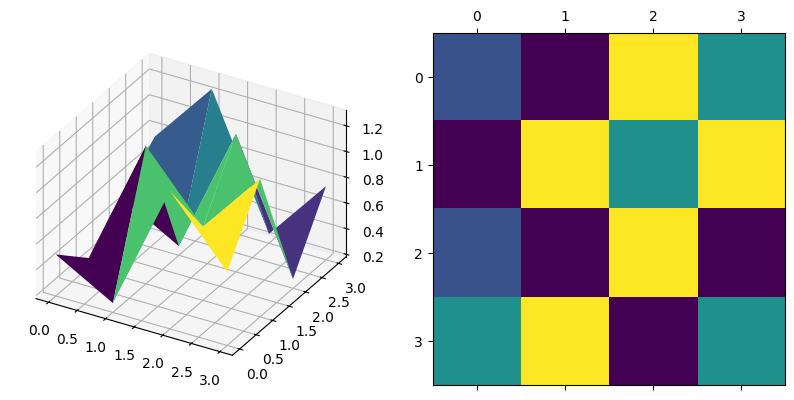

In [10]:
#Creazione del dato e visualizzazione
#1. Definiamo la griglia dei punti
#1.a partizione dell'asse delle ascisse
a,b = (0,3)
n   = 4
x = np.linspace(a,b,n)
y = np.linspace(a,b,n)
#1.b creazione delle coordinate dei punti della griglia
X, Y = np.meshgrid(x,y)
#1.c creazione della matrice dei dati
Z = np.array([[0.5,0.25, 1.25, 0.75], [0.25, 1.25, 0.75, 1.25],[0.5, 0.25, 1.25, 0.25],[0.75, 1.25, 0.25, 0.75]])

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,2,1, projection='3d',proj_type='ortho')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax2= fig.add_subplot(1,2,2)
ax2.matshow(Z)
plt.show()

In [11]:
#Raffinamento della griglia
N = 5 #fattore di duplicazione
x2 = np.linspace(a, b, 2**N*(n -1) + 1 )
y2 = np.linspace(a, b, 2**N*(n -1) + 1 )

X2, Y2 = np.meshgrid(x2, y2)
print(x2)
print(x2.size)

[0.      0.03125 0.0625  0.09375 0.125   0.15625 0.1875  0.21875 0.25
 0.28125 0.3125  0.34375 0.375   0.40625 0.4375  0.46875 0.5     0.53125
 0.5625  0.59375 0.625   0.65625 0.6875  0.71875 0.75    0.78125 0.8125
 0.84375 0.875   0.90625 0.9375  0.96875 1.      1.03125 1.0625  1.09375
 1.125   1.15625 1.1875  1.21875 1.25    1.28125 1.3125  1.34375 1.375
 1.40625 1.4375  1.46875 1.5     1.53125 1.5625  1.59375 1.625   1.65625
 1.6875  1.71875 1.75    1.78125 1.8125  1.84375 1.875   1.90625 1.9375
 1.96875 2.      2.03125 2.0625  2.09375 2.125   2.15625 2.1875  2.21875
 2.25    2.28125 2.3125  2.34375 2.375   2.40625 2.4375  2.46875 2.5
 2.53125 2.5625  2.59375 2.625   2.65625 2.6875  2.71875 2.75    2.78125
 2.8125  2.84375 2.875   2.90625 2.9375  2.96875 3.     ]
97


In [12]:
#nearest_neighbor
def duplica(Z): #esercizio 11
  n,m = Z.shape
  T = np.zeros((2*n-1,2*m-1))
  T[::2,::2] = Z[:,:]
  T[:,1::2] = T[:,:-1:2]
  T[1::2,:] = T[:-1:2,:]
  return T

def nearest_n(Z,N=1):
  T = Z.copy()
  for i in range(N):
    T = duplica(T)
  return T
Z2 = nearest_n(Z,N=N)
print(Z2.shape)

(97, 97)


(97, 97)


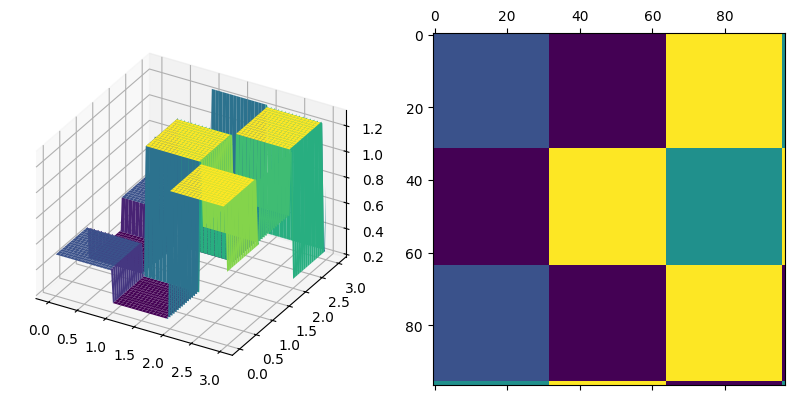

In [13]:

Z2 = nearest_n(Z,N=N)
print(Z2.shape)

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,2,1, projection='3d',proj_type='ortho')
ax.plot_surface(X2, Y2, Z2, cmap='viridis', edgecolor='none')

ax2= fig.add_subplot(1,2,2)
ax2.matshow(Z2)

In [14]:
from scipy.interpolate import RegularGridInterpolator

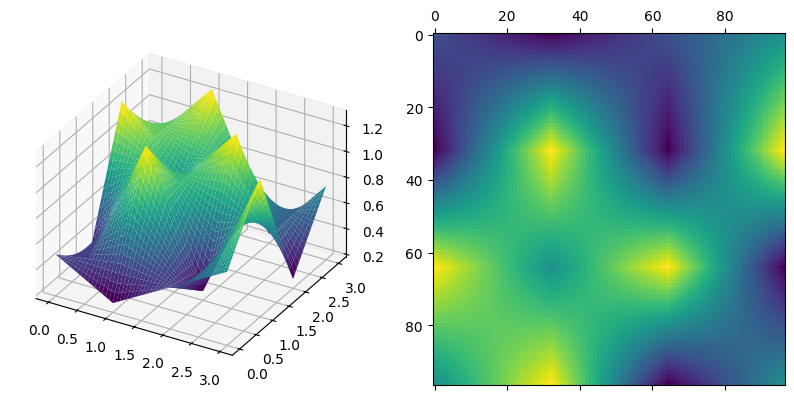

In [15]:
#Interpolazione bilineare

bilin_interp = RegularGridInterpolator((x, y), Z, method="linear")
Zb = bilin_interp((X2, Y2))

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,2,1, projection='3d',proj_type='ortho')
ax.plot_surface(X2, Y2, Zb, cmap='viridis', edgecolor='none')

ax2= fig.add_subplot(1,2,2)
ax2.matshow(Zb)
plt.show()

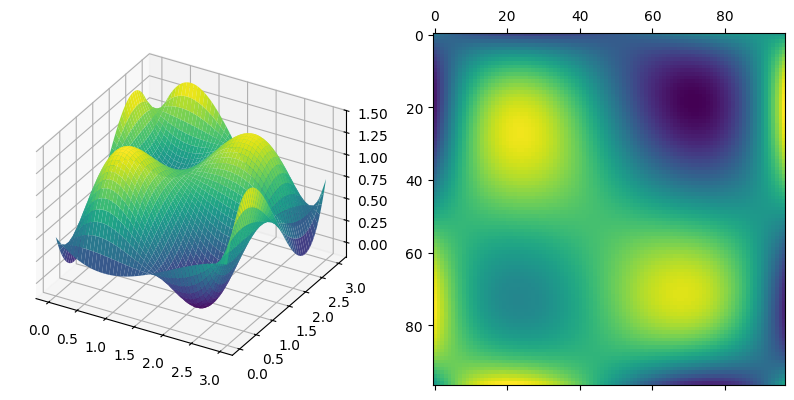

In [16]:
#Interpolazione spline cubica 2D

cubic_spline_interp = RegularGridInterpolator((x, y), Z, method="cubic")
Zs = cubic_spline_interp((X2, Y2))

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,2,1, projection='3d',proj_type='ortho')
ax.plot_surface(X2, Y2, Zs, cmap='viridis', edgecolor='none')

ax2= fig.add_subplot(1,2,2)
ax2.matshow(Zs)
plt.show()